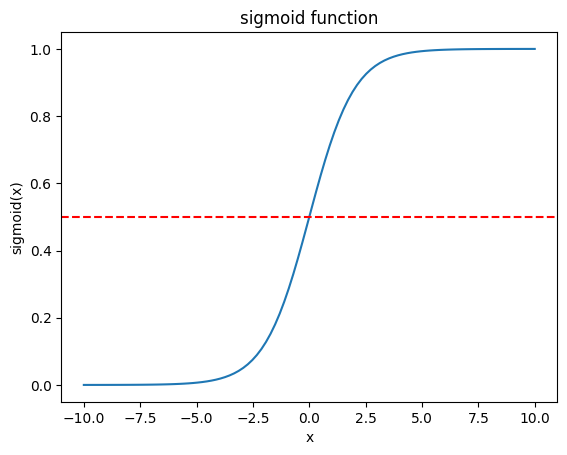

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 100)
y = sigmoid(x)

plt.plot(x, y)
plt.axhline(y=0.5, color='r', linestyle='--')  # 0.5のライン
plt.xlabel("x")
plt.ylabel("sigmoid(x)")
plt.title("sigmoid function")
plt.show()

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# ポジティブ・ネガティブのレビューデータ
corpus = [
    "this movie is great and amazing",
    "wonderful film loved every moment",
    "fantastic story brilliant acting",
    "excellent movie highly recommend",
    "best film I have ever seen",
    "this movie is terrible and boring",
    "awful film waste of time",
    "horrible story bad acting",
    "worst movie I have ever seen",
    "completely disappointed very bad",
]

# 0がネガティブ・1がポジティブ
labels = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]

# TF-IDFでベクトル化
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(corpus)

print("データの形:", X.shape)

データの形: (10, 34)


In [4]:
# 学習データとテストデータに分割する
X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.3, random_state=42
)

print("学習データ数:", X_train.shape[0])
print("テストデータ数:", X_test.shape[0])

# ロジスティック回帰で学習
model = LogisticRegression()
model.fit(X_train, y_train)

# テストデータで予測
y_pred = model.predict(X_test)
print("\n予測結果:", y_pred)
print("正解ラベル:", y_test)

学習データ数: 7
テストデータ数: 3

予測結果: [1 1 1]
正解ラベル: [0, 1, 0]


In [5]:
# 精度を確認する
print("accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

accuracy: 0.3333333333333333

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



/home/qqqlq-desk/projects/nlp/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/qqqlq-desk/projects/nlp/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/qqqlq-desk/projects/nlp/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

In [7]:
# データを増やす
corpus2 = [
    "this movie is great and amazing",
    "wonderful film loved every moment",
    "fantastic story brilliant acting",
    "excellent movie highly recommend",
    "best film I have ever seen",
    "really enjoyed this beautiful film",
    "superb acting and great story",
    "loved it perfect movie",
    "this movie is terrible and boring",
    "awful film waste of time",
    "horrible story bad acting",
    "worst movie I have ever seen",
    "completely disappointed very bad",
    "dull and boring film avoid",
    "terrible acting poor story",
    "hated every moment very disappointing",
]

labels2 = [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]

# TF-IDFでベクトル化
tfidf2 = TfidfVectorizer()
X2 = tfidf2.fit_transform(corpus2)

# 分割・学習・評価
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, labels2, test_size=0.3, random_state=42
)

model2 = LogisticRegression()
model2.fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2)

print("\n予測結果:", y_pred2)
print("正解ラベル:", y_test2)

print("accuracy:", accuracy_score(y_test2, y_pred2))
print()
print(classification_report(y_test2, y_pred2))


予測結果: [0 0 0 0 0]
正解ラベル: [1, 1, 1, 0, 0]
accuracy: 0.4

              precision    recall  f1-score   support

           0       0.40      1.00      0.57         2
           1       0.00      0.00      0.00         3

    accuracy                           0.40         5
   macro avg       0.20      0.50      0.29         5
weighted avg       0.16      0.40      0.23         5



/home/qqqlq-desk/projects/nlp/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/qqqlq-desk/projects/nlp/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/qqqlq-desk/projects/nlp/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

In [8]:
from sklearn.datasets import load_files
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import urllib.request
import tarfile
import os

# IMDbレビューデータセットをダウンロードする
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
filename = "aclImdb_v1.tar.gz"

if not os.path.exists("aclImdb"):
    print("ダウンロード中...")
    urllib.request.urlretrieve(url, filename)
    print("解凍中...")
    with tarfile.open(filename) as tar:
        tar.extractall()
    print("完了!")
else:
    print("データセットは既に存在します")

ダウンロード中...
解凍中...
完了!


In [10]:
# 学習データを読み込む
train_data = load_files("aclImdb/train", categories=["pos", "neg"],
                        encoding="utf-8")

X_train_raw = train_data.data    # レビューテキスト
y_train = train_data.target      # 0がneg・1がpos

print("学習データ数:", len(X_train_raw))
print("ラベルの種類:", train_data.target_names)
print("\nレビュー例:")
print(X_train_raw[0][:200])  # 最初のレビューの最初の200文字

学習データ数: 25000
ラベルの種類: ['neg', 'pos']

レビュー例:
Zero Day leads you to think, even re-think why two boys/young men would do what they did - commit mutual suicide via slaughtering their classmates. It captures what must be beyond a bizarre mode of be


In [ ]:
# テストデータも読み込む
test_data = load_files("aclImdb/test", categories=["pos", "neg"],
                       encoding="utf-8")

X_test_raw = test_data.data
y_test = test_data.target

print("テストデータ数:", len(X_test_raw))

# TF-IDFでベクトル化
# 学習データでfitしてテストデータはtransformだけする
tfidf = TfidfVectorizer(max_features=10000)  # 頻出上位10000単語だけ使う
X_train = tfidf.fit_transform(X_train_raw)
X_test = tfidf.transform(X_test_raw)  # fit_transformではなくtransformだけ

print("学習データの形:", X_train.shape)
print("テストデータの形:", X_test.shape)